In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [39]:
df_tr = pd.read_csv('D:\\repos\\ML_innovise\\data\\processed\\df_train_eda.csv')
df_test = pd.read_csv('D:\\repos\\ML_innovise\\data\\processed\\df_test_eda.csv')

In [40]:
df_testt = pd.read_csv(r'D:\ML_innovise\test.csv')
df_test = df_test.merge(
    df_testt,
    on = ['shop_id','item_id'],
    how = 'left'
)

In [41]:
from Splitter import Splitter

splitter = Splitter('date_block_num', 33)


In [42]:
features =['cnt_lag_1','cnt_lag_3','cnt_lag_2','cnt_lag_12', 'cnt_rm_3','cnt_rm_6','item_avg_price_prev', 'item_price','date_block_num','avg_price_prev_missing']
X_tr, y_tr, X_val, y_val = splitter.split(df_tr, features,'item_cnt_month')


In [6]:
X_tr_full = pd.concat([X_tr, X_val], axis = 0)
y_tr_full = pd.concat([y_tr, y_val])

In [7]:
from sklearn.ensemble import RandomForestRegressor


In [ ]:

modelRFR = RandomForestRegressor(n_estimators = 200, max_depth = 10, random_state= 42, n_jobs = -1)

In [7]:
modelRFR.fit(X_tr,y_tr)

,n_estimators,200
,criterion,'squared_error'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [8]:
imp = pd.Series(modelRFR.feature_importances_, index = X_tr.columns).sort_values(ascending=False)

In [9]:
imp

item_price                0.565264
cnt_lag_1                 0.324928
cnt_rm_6                  0.050793
item_avg_price_prev       0.024062
date_block_num            0.018359
cnt_lag_3                 0.009237
cnt_lag_2                 0.005839
cnt_lag_12                0.001424
avg_price_prev_missing    0.000095
dtype: float64

item_price + cnt_lag_1 дают почти 90 процентов важности

Интересный факт: цена имеет наибольшую важность, но корреляция у цены с таргетом маленькая (0.35)

Значит скорее всего присутствует какая-то коварная нелинейная связь между ними.

In [10]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(modelRFR, X_val, y_val, n_repeats = 10, random_state = 42, n_jobs = -1)
 

In [11]:
perm_imp = pd.Series(perm.importances_mean, index = X_val.columns).sort_values(ascending=False)
perm_imp 

item_price                0.865597
cnt_lag_1                 0.109554
cnt_rm_6                  0.051026
item_avg_price_prev       0.024206
cnt_lag_2                 0.003526
cnt_lag_3                 0.003377
cnt_lag_12                0.002025
avg_price_prev_missing    0.000003
date_block_num            0.000000
dtype: float64

видим, что  после перестановки топовые лидеры по важности: item_price   cnt_lag_1   cnt_rm_6

In [8]:
from hyperopt import hp, Trials, fmin, tpe, STATUS_OK

d:\repos\ML_innovise\.venv\Lib\site-packages\hyperopt\atpe.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [9]:
from sklearn.model_selection import cross_val_score, TimeSeriesSplit

In [31]:
space = {
    'n_estimators': hp.choice('n_estimators', [50, 100] ),
    'max_depth': hp.choice('max_depth', [5,10]),
    'min_samples_split': hp.quniform('min_samples_split', 2,5,1),
    'min_samples_leaf': hp.quniform('min_samples_leaf', 1, 3, 1),
}

splitter = TimeSeriesSplit(n_splits = 5)

def objective(params):
    params['min_samples_leaf'] = int(params['min_samples_leaf'])
    params['min_samples_split'] = int(params['min_samples_split'])

    model = RandomForestRegressor(
        n_estimators = params['n_estimators'],
        max_depth = params['max_depth'],
        min_samples_split = params['min_samples_split'],
        min_samples_leaf=params['min_samples_leaf'],
        random_state=42
        )
    metric = cross_val_score(model, X_tr, y_tr, cv = splitter, scoring = 'neg_mean_squared_error', n_jobs = -1).mean()
    return {
        'loss': -metric,
        'status': STATUS_OK
    }

trials = Trials()
best = fmin(
    fn = objective,
    space = space,
    algo = tpe.suggest,
    max_evals = 30,
    trials = trials,
)

print(best)



100%|██████████| 30/30 [2:44:46<00:00, 329.56s/trial, best loss: 0.4027374525028648] 
{'max_depth': np.int64(1), 'min_samples_leaf': np.float64(3.0), 'min_samples_split': np.float64(5.0), 'n_estimators': np.int64(1)}


получается имеем:
# -> {'n_estimators': 100,
#     'max_depth': 10,
#     'min_samples_split': 5,
#     'min_samples_leaf': 3}

In [33]:
n_estimators_list = [50, 100]
max_depth_list    = [5, 10]

best_params = {
    'n_estimators':      n_estimators_list[ int(best['n_estimators']) ],
    'max_depth':         max_depth_list[    int(best['max_depth'])    ],
    'min_samples_split': int(best['min_samples_split']),
    'min_samples_leaf':  int(best['min_samples_leaf'])
}

final_model = RandomForestRegressor(
    **best_params,
    random_state=42,
    n_jobs=-1
)
final_model.fit(X_tr, y_tr)

,n_estimators,100
,criterion,'squared_error'
,max_depth,10
,min_samples_split,5
,min_samples_leaf,3
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [34]:
preds = final_model.predict(df_test[features])


In [35]:
submission = pd.DataFrame({
    "ID":              df_test["ID"],
    "item_cnt_month":  preds
})

In [36]:
submission.to_csv("RFR_Hyperopt.csv", index=False)

Результат - 1.23658

In [9]:
space = {
    'n_estimators': hp.choice('n_estimators', [100, 150] ),
    
}

splitter = TimeSeriesSplit(n_splits = 5)

def objective(params):
    

    model = RandomForestRegressor(
        n_estimators = params['n_estimators'],
        random_state=42
        )
    metric = cross_val_score(model, X_tr, y_tr, cv = splitter, scoring = 'neg_mean_squared_error', n_jobs = -1).mean()
    return {
        'loss': -metric,
        'status': STATUS_OK
    }

trials = Trials()
best = fmin(
    fn = objective,
    space = space,
    algo = tpe.suggest,
    max_evals = 30,
    trials = trials,
)

print(best)



 30%|███       | 9/30 [5:19:40<12:25:54, 2131.16s/trial, best loss: 0.34743704816226834]


KeyboardInterrupt: 

In [8]:
from sklearn.linear_model import Ridge

In [23]:
space = {
    'alpha': hp.loguniform('alpha', np.log(1e-4), np.log(1e2))
}
tscv = TimeSeriesSplit(n_splits=5)
def objective(params):
    model = Ridge(alpha = params['alpha'], random_state = 42)
    metric = cross_val_score(model, X_tr, y_tr, cv = tscv, scoring  = 'neg_mean_squared_error', n_jobs = -1).mean()
    return{
        'loss': -metric,
        'status': STATUS_OK
    }
trials = Trials()
best = fmin(fn = objective, space = space, algo = tpe.suggest, max_evals = 15, trials = trials, )
print('Best alpha:', best['alpha'])

100%|██████████| 15/15 [00:50<00:00,  3.40s/trial, best loss: 0.6061698965738761]
Best alpha: 0.00038128326956847947


In [26]:
alpha_opt = best['alpha']
model = Ridge(alpha = alpha_opt)
model.fit(X_tr, y_tr)
preds = model.predict(df_test[features])


In [27]:
submission = pd.DataFrame({
    "ID":              df_test["ID"],
    "item_cnt_month":  preds
})

In [28]:
submission.to_csv("RidgeAlphaOpt2.csv", index=False)

Результат - 1.03091

In [7]:
import xgboost as xgb

In [21]:
space = {
    'max_depth': hp.choice('max_depth', np.arange(3,13,dtype = int)),
    'learning_rate': hp.loguniform('learning_rate', np.log(0.01), np.log(0.2)),
    'n_estimators': hp.choice('n_estimators', np.arange(100,701, 100, dtype = int)),
}

In [22]:
tscv = TimeSeriesSplit(n_splits=3)


In [24]:
def objective(params):
    model = xgb.XGBRegressor(**params, objective = 'reg:squarederror', random_state = 42, n_jobs  = -1)
    scores = cross_val_score(model, X_tr_full, y_tr_full,  scoring = 'neg_root_mean_squared_error', cv = tscv, n_jobs = -1)
    rmse_mean = -scores.mean()
    return{
        'loss': rmse_mean,
        'status': STATUS_OK
    }


In [25]:
trials = Trials()
best = fmin(fn = objective, space = space, algo = tpe.suggest, max_evals = 50, trials = trials)
print(best)

100%|██████████| 50/50 [2:41:21<00:00, 193.63s/trial, best loss: 0.5891115539691306]  
{'learning_rate': np.float64(0.049476130747775356), 'max_depth': np.int64(7), 'n_estimators': np.int64(5)}


In [26]:
from hyperopt import space_eval


In [27]:
best_params = space_eval(space, best)
print(best_params)

{'learning_rate': 0.049476130747775356, 'max_depth': np.int64(10), 'n_estimators': np.int64(600)}


Получается лучшие параметры:

- learning_rate': 0.049476130747775356
- 'max_depth': 10
- 'n_estimators': 600

In [8]:
best_model = xgb.XGBRegressor(learning_rate = 0.049476130747775356, max_depth = 10, n_estimators = 600)

In [9]:
best_model.fit(X_tr_full, y_tr_full)
X_test = df_test[features]
pred = best_model.predict(X_test)

In [33]:
submission = pd.DataFrame({
    "ID":              df_test["ID"],
    "item_cnt_month":  pred
})

In [34]:
# результат на кагле - 
submission.to_csv("XGB_hyperopt.csv", index=False)

In [10]:
import shap

d:\repos\ML_innovise\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [11]:
segments = []
for start in np.random.choice(range(len(X_tr_full)-5), size=20, replace=False):
    segments.append(X_tr_full.iloc[start:start+5])
background = pd.concat(segments)


In [12]:
explainer = shap.TreeExplainer(best_model, data = background)


In [18]:
idx = 100
instance = X_test.iloc[[idx]]
shap_values = explainer(instance)

In [19]:
base = shap_values.base_values[0]
contributions = shap_values.values[0]

print("base value", base)
print("feature contributions:", contributions)# Видим, какие признаки тянут прогноз вверх (короче положительные вклады) и вниз (отрицательные).

base value 0.024902369933329675
feature contributions: [-4.76784073e-06  3.02610359e-06 -2.16288481e-05  0.00000000e+00
 -3.34144680e-06 -9.97380737e-06 -2.61227773e-03 -2.20580664e-02
 -1.33892662e-04  5.59465457e-06]


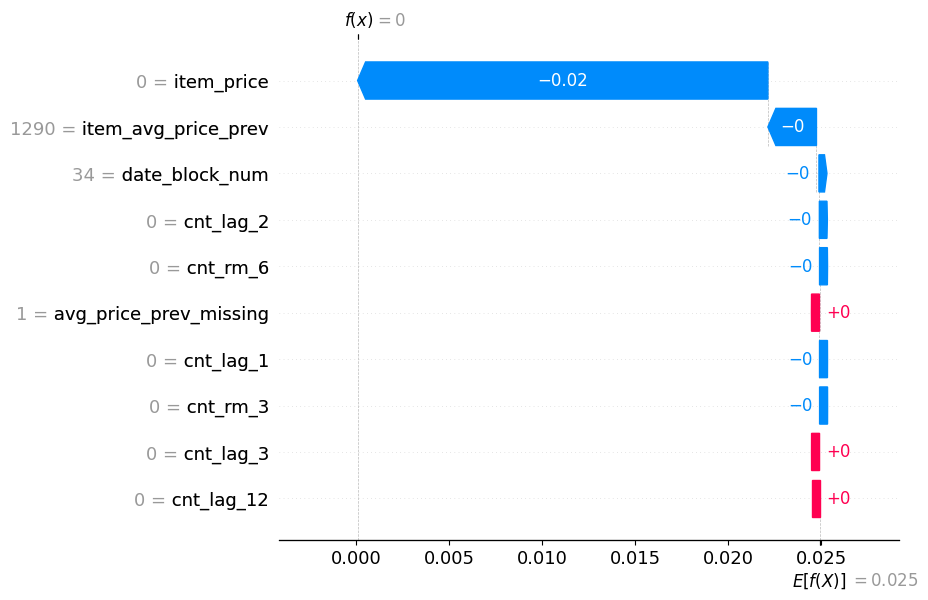

In [20]:
# это наш waterfall график, который поможет посмотреть, как каждый признак вел наше предсказание до самого конца 
shap.waterfall_plot(shap_values[0])


In [21]:
pd.DataFrame({
    'feature': X_test.columns,
    'shap_value': contributions
}).sort_values('shap_value', ascending=False)


,feature,shap_value
9,avg_price_prev_missing,0.000006
1,cnt_lag_3,0.000003
3,cnt_lag_12,0.000000
4,cnt_rm_3,-0.000003
0,cnt_lag_1,-0.000005
5,cnt_rm_6,-0.000010
2,cnt_lag_2,-0.000022
8,date_block_num,-0.000134
6,item_avg_price_prev,-0.002612
7,item_price,-0.022058


Слой анализа ошибок:
- найти слабые места модели
- как предсказывает большие значения таргета
- оценить точность прогноза при большой\малой дин

Я решила, поскольку лучший результат дала Линейная регрессия, то слой анализа ошибок я буду делать именно для нее. 
Возьмем и обучим на первых 32 месяцах, а ошибки проверим на 33 валидационном датасете.

In [7]:
from sklearn.linear_model import LinearRegression

In [43]:
modelLR = LinearRegression()

In [44]:
modelLR.fit(X_tr, y_tr)
y_pred = modelLR.predict(X_val)

In [45]:
df_val = X_val.copy()
df_val['y_true'] = y_val
df_val['y_pred'] = y_pred
df_val['residual'] = df_val['y_true'] - df_val['y_pred']
df_val['abs_err'] = df_val['residual'].abs()

In [11]:
from sklearn.metrics import mean_squared_error

In [46]:
rmse = np.sqrt(mean_squared_error(df_val['y_true'], df_val['y_pred']))
print(rmse)

0.9030601847802211


In [66]:
s = df_val['y_true'].where(df_val['y_true'] > 0)

pos_bins = pd.qcut(s, q=20, labels=False, duplicates='drop')

df_val['y_bin'] = pos_bins.fillna(0).astype(int)


In [67]:
# теперь посчитаем rmse на каждом бине
rmse_by_level = df_val.groupby('y_bin').apply(lambda g: np.sqrt(mean_squared_error(g['y_true'], g['y_pred']))).reset_index(name = 'rmse')


C:\Users\Barys\AppData\Local\Temp\ipykernel_12772\1348442113.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rmse_by_level = df_val.groupby('y_bin').apply(lambda g: np.sqrt(mean_squared_error(g['y_true'], g['y_pred']))).reset_index(name = 'rmse')


In [68]:
rmse_by_level

,y_bin,rmse
0,0,0.535779
1,1,2.291426
2,2,3.091266
3,3,8.269832


Видим, что чем больше номер группы, тем выше ошибка. Получается модель работает хуже всего с крупными предсказаниями.

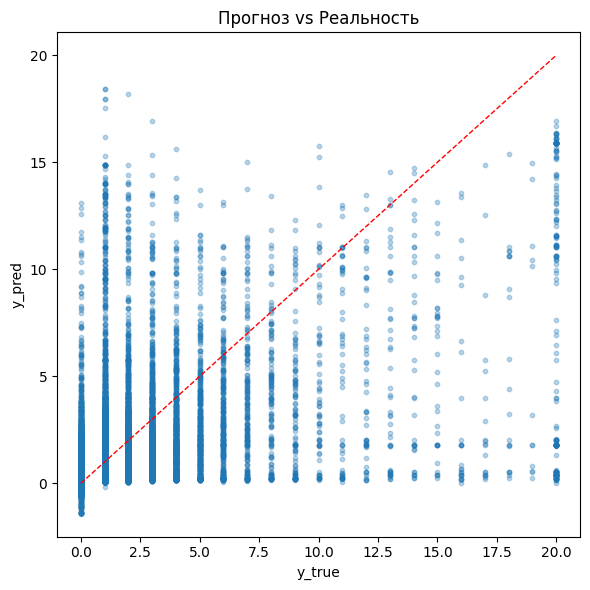

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(df_val['y_true'], df_val['y_pred'], alpha=0.3, s=10)
plt.plot([0, df_val['y_true'].max()],
         [0, df_val['y_true'].max()],
         'r--', linewidth=1)
plt.xlabel('y_true')
plt.ylabel('y_pred')
plt.title('Прогноз vs Реальность')
plt.tight_layout()
plt.show()


Что можем сказать с графика:
В идеале чтобы прогнозы размещались на главной диагонали (что логично, ведь главная диагональ - это место, где совпали y_true и y_pred - значит сделали хорошее предсказание)

Большинство точек лежит ниже главной диагонали - значит модель недооценивает большие значения.


анализируя этот график и изучая полезную информацию я узнала, что можно делать лог трансформацию таргета и обратно, решила попробовать:


In [73]:
y_tr_full_log = np.log1p(y_tr_full)

In [74]:
modelLRlog = LinearRegression()
modelLRlog.fit(X_tr_full, y_tr_full_log)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [76]:
X_test = df_test[features]

In [77]:
y_pred_log = modelLRlog.predict(X_test)
y_pred = np.expm1(y_pred_log)

In [78]:
submission = pd.DataFrame({
    "ID":              df_test["ID"],
    "item_cnt_month":  y_pred
})

submission.to_csv("submissionLRlog.csv", index=False)

Результат - 1.10005 - фигня, короче лучше картинку это нам не сделало :(

Возвращаемся дальше к слою анализа ошибок

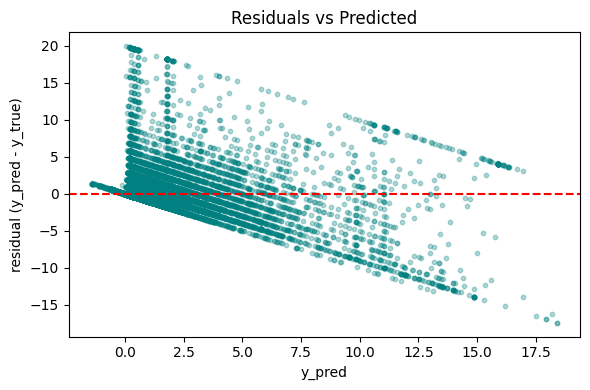

In [79]:
plt.figure(figsize=(6,4))
plt.scatter(df_val['y_pred'], df_val['residual'], 
            alpha=0.3, s=10, color='teal')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('y_pred')
plt.ylabel('residual (y_pred - y_true)')
plt.title('Residuals vs Predicted')
plt.tight_layout()
plt.show()

Построили график остатков, что я могу о нем сказать:
- то, что и говорилось ранее - значения маленькие таргета и их предсказанные концентрируются около нуля, то есть модель с малыми значениями справлчется хорошо, но чем выше значение таргета -  тем больше она его недооценивает
- средних у нас в принципе не так много в таргете, модель с ними не так плохо справляется